
# Lab 2 — Image Processing & Filtering (Student Implementation)

**Course:** 4-COV-10-413 · Computer Vision  
**Runtime:** Google Colab  
**Policy:** You must implement core functions yourself. Using `cv2`/`scipy` is allowed **only in the comparison cells**. Copy–pasting complete solutions from the web is not allowed.

**Learning Goals**
- Implement 2D convolution from scratch.
- Build and apply Gaussian, Sobel, and Laplacian filters.
- (Optional) Design a frequency-domain filter with the FFT.
- Compare your results with library functions and reflect on differences.

> **Deliverable:** Submit this completed notebook (all cells executed) with your short reflections.


In [2]:

# ==== Setup (re-run if runtime resets) ====
!pip -q install opencv-python-headless scikit-image

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, img_as_float
from google.colab import files

print("Versions -> numpy:", np.__version__, "| opencv:", cv2.__version__)


Versions -> numpy: 2.1.3 | opencv: 5.0.0


In [3]:

# ==== Display Helpers (do not modify) ====
import numpy as np
import matplotlib.pyplot as plt

def imshow(img, title=None, cmap=None, size=4, isOpencv=True):
    plt.figure(figsize=(size, size))
    if cmap is not None:
        plt.imshow(img, cmap=cmap)
    else:
        if img.ndim == 3 and img.shape[-1] == 3 and isOpencv:
            img = img[..., ::-1]  # BGR->RGB heuristic
        plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

def show_side_by_side(imgs, titles=None, cmaps=None, size=4, isOpencv=[]):
    n = len(imgs)
    plt.figure(figsize=(size*n, size))
    for i, im in enumerate(imgs):
        plt.subplot(1, n, i+1)
        cmap = None if cmaps is None else cmaps[i]
        if cmap is not None:
            plt.imshow(im, cmap=cmap)
        else:
            if im.ndim == 3 and im.shape[-1] == 3 and len(isOpencv)==n and isOpencv[i]:
                im = im[..., ::-1]
            plt.imshow(im)
        if titles:
            plt.title(titles[i])
        plt.axis("off")
    plt.show()



## Part 0 — Data
Use the built-in sample image for deterministic checks and feel free to upload one of your own.


RGB: (512, 512, 3) uint8 | Gray: (512, 512) uint8


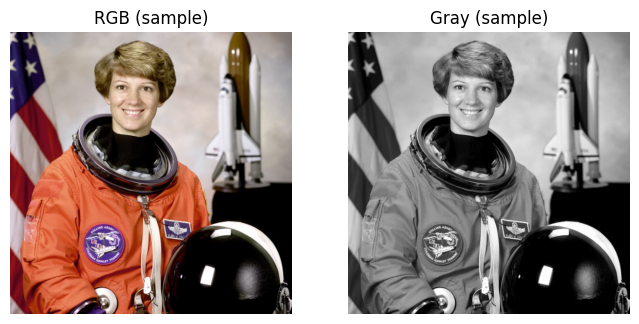

KeyboardInterrupt: 

In [4]:

# Built-in sample (RGB float in [0,1]), convert to uint8
img_rgb = (img_as_float(data.astronaut()) * 255).astype(np.uint8)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

print("RGB:", img_rgb.shape, img_rgb.dtype, "| Gray:", img_gray.shape, img_gray.dtype)
show_side_by_side([img_rgb, img_gray], ["RGB (sample)", "Gray (sample)"], [None, "gray"], size=4)

# Optional: upload your own
uploaded = files.upload()
user_imgs = {}
for name, content in uploaded.items():
    file_bytes = np.frombuffer(content, np.uint8)
    img_cv = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)  # BGR uint8
    user_imgs[name] = img_cv
    imshow(img_cv, f"Uploaded: {name}")
print("Uploaded:", list(user_imgs.keys()))



---
## Part A — Implement 2D Convolution (from scratch)
**Task:** Implement `my_convolve2d(image, kernel)` using nested loops.  
- Grayscale input, odd kernel sizes.  
- Use zero or reflect padding (state your choice).  
- Return same image size. Clip to `[0,255]` if needed.


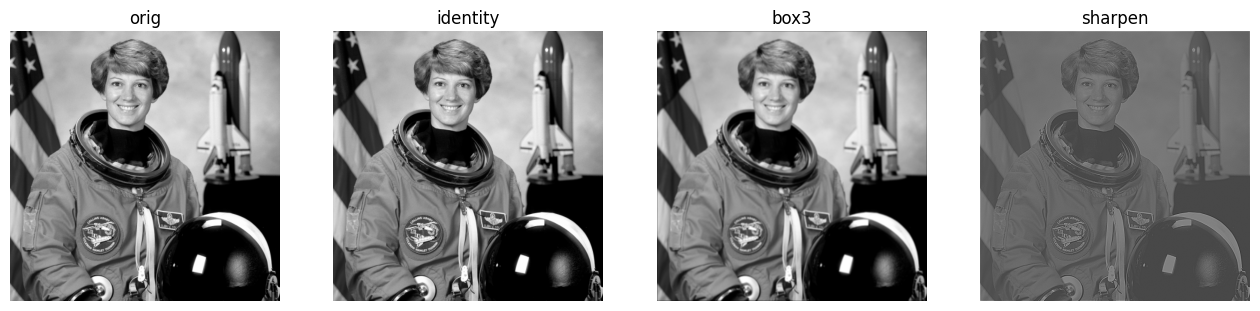

In [5]:
def my_convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Implement 2D convolution using nested loops (no cv2/scipy)."""
    # TODO: STUDENT IMPLEMENTATION
    # Formula of output image: given (N, N) and (K, K) -> (N-K+1, N-K+1) with stride 1

    n_im, m_im = image.shape
    n_k, m_k = kernel.shape
    pad_h = n_k // 2
    pad_w = m_k // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant",
        constant_values=0
    )

    out_img = np.zeros((n_im, m_im))

    for i in range(n_im):
        for j in range(m_im):

            patch = padded[i:i+n_k, j:j+m_k]
            out_img[i, j] = np.sum(patch * kernel)

    return out_img


# Sanity kernels
identity = np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=float)
box3 = np.ones((3,3), dtype=float) / 9.0
sharpen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float)

# # Uncomment after implementing:
out_id = my_convolve2d(img_gray, identity)
out_box = my_convolve2d(img_gray, box3)
out_sharp = my_convolve2d(img_gray, sharpen)
show_side_by_side([img_gray, out_id, out_box, out_sharp],
                  ["orig", "identity", "box3", "sharpen"],
                  ["gray","gray","gray","gray"], size=4)



### A.1 — Compare with OpenCV (validation only)


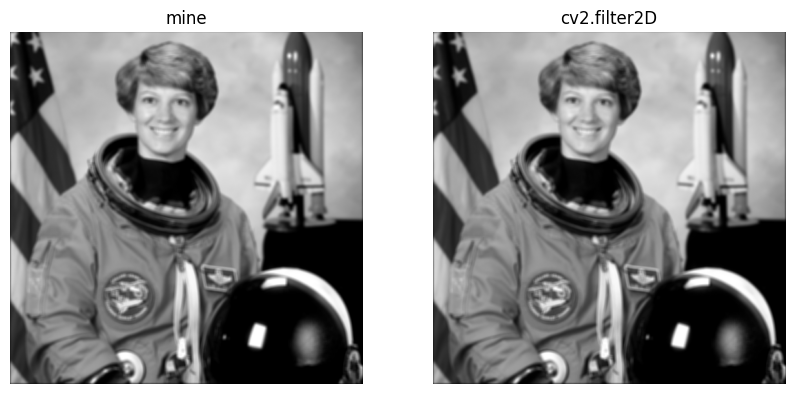

L1 diff: 0.22669375


In [6]:
# Uncomment after implementing
out_box_mine = my_convolve2d(img_gray, np.ones((5,5))/25.0)
out_box_cv = cv2.filter2D(img_gray, ddepth=-1, kernel=np.ones((5,5), dtype=float)/25.0, borderType=cv2.BORDER_CONSTANT)
show_side_by_side([out_box_mine, out_box_cv], ["mine", "cv2.filter2D"], ["gray","gray"], size=5)
print("L1 diff:", np.mean(np.abs(out_box_mine.astype(np.float32)-out_box_cv.astype(np.float32))))



---
## Part B — Gaussian Filtering (build kernel yourself)
Implement `my_gaussian_kernel(size, sigma)` and apply it using your convolution.


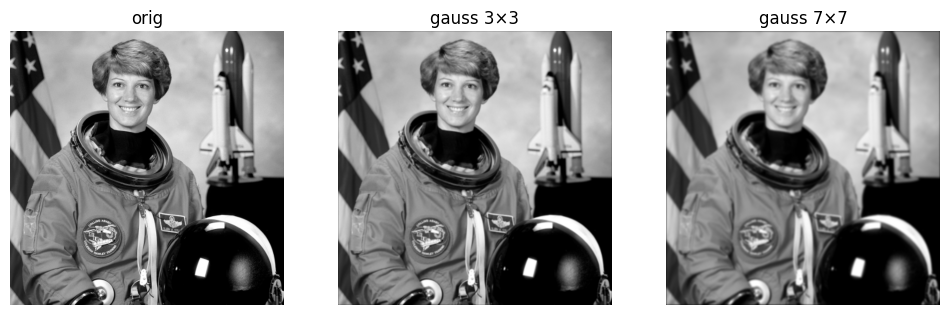

In [7]:
def my_gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """Return a normalized size×size Gaussian kernel."""

    # Coordinates centered around 0
    radius = size // 2
    x = np.arange(-radius, radius + 1)
    y = np.arange(-radius, radius + 1)

    # Create 2D coordinate grid
    X, Y = np.meshgrid(x, y)

    # 2D Gaussian formula
    kernel = np.exp(
        -(X**2 + Y**2) / (2 * sigma**2)
    )

    # Normalize so that kernel sums to 1
    kernel /= kernel.sum()

    return kernel

# Uncomment after implementing:
g3 = my_gaussian_kernel(3, 0.8)
g7 = my_gaussian_kernel(7, 1.6)
out_g3 = my_convolve2d(img_gray, g3)
out_g7 = my_convolve2d(img_gray, g7)
show_side_by_side([img_gray, out_g3, out_g7], ["orig", "gauss 3×3", "gauss 7×7"], ["gray","gray","gray"])



### B.1 — Compare with `cv2.GaussianBlur` (validation)


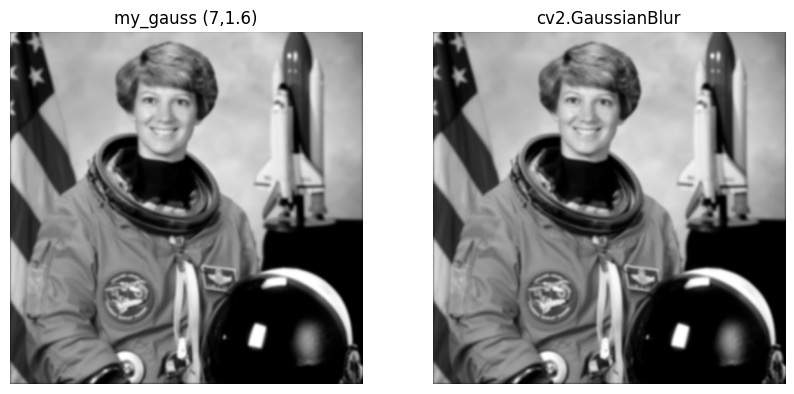

In [8]:

# # Uncomment after implementing:
out_cv = cv2.GaussianBlur(img_gray, (7,7), 1.6, borderType=cv2.BORDER_CONSTANT)
show_side_by_side([out_g7, out_cv], ["my_gauss (7,1.6)", "cv2.GaussianBlur"], ["gray","gray"], size=5)



---
## Part C — Sobel Edge Detection (with your convolution)
Compute Gx, Gy via Sobel kernels and the gradient magnitude image.


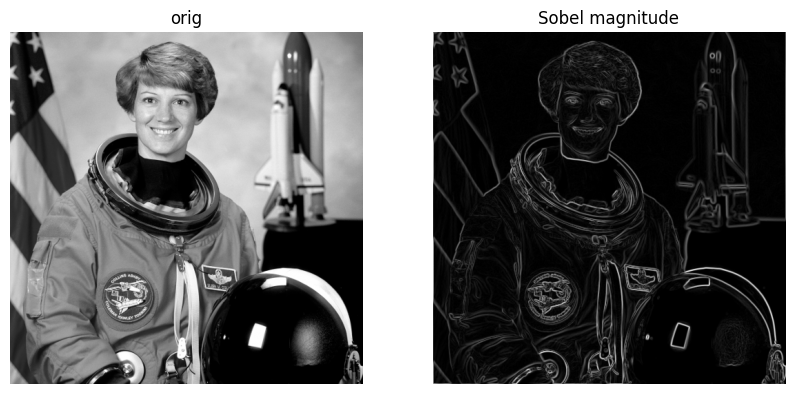

In [9]:

# TODO: STUDENT IMPLEMENTATION
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)
sobel_y = sobel_x.T
Gx = my_convolve2d(img_gray, sobel_x)
Gy = my_convolve2d(img_gray, sobel_y)

# Gradient magnitude
G = np.sqrt(Gx**2 + Gy**2)
G = G / G.max() * 255
G = G.astype(np.uint8)

show_side_by_side([img_gray, G], ["orig", "Sobel magnitude"], ["gray","gray"], size=5)
pass



### C.1 — Compare with OpenCV Sobel (validation)


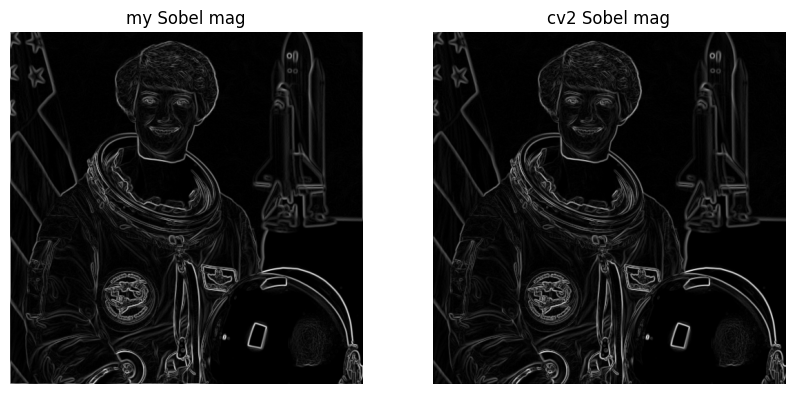

In [10]:
# Uncomment after implementing:
gx_cv = cv2.Sobel(img_gray, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=3)
gy_cv = cv2.Sobel(img_gray, ddepth=cv2.CV_32F, dx=0, dy=1, ksize=3)
g_cv = np.sqrt(gx_cv**2 + gy_cv**2)
g_cv = (255*(g_cv / (g_cv.max()+1e-8))).astype(np.uint8)
show_side_by_side([G, g_cv], ["my Sobel mag", "cv2 Sobel mag"], ["gray","gray"], size=5)



---
## Part D — Laplacian (second derivative)
Apply a 3×3 Laplacian kernel via your convolution and compare with Sobel magnitude.


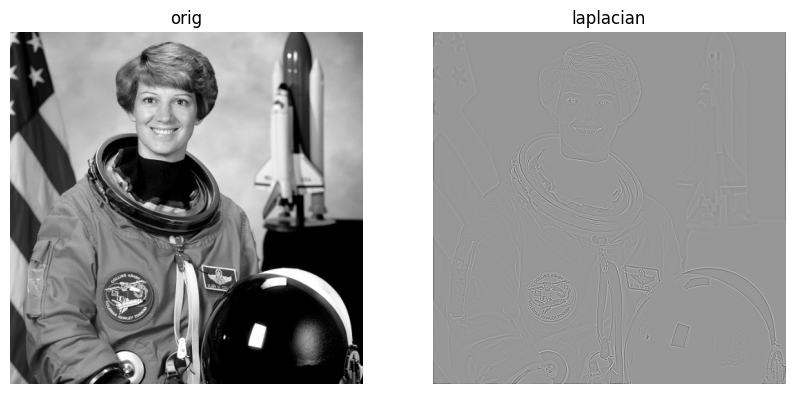

In [11]:

# TODO: STUDENT IMPLEMENTATION
lap = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=float)
out_lap = my_convolve2d(img_gray, lap)
show_side_by_side([img_gray, out_lap], ["orig", "laplacian"], ["gray","gray"], size=5)
pass



---
## Part E (Optional) — Frequency-Domain Filtering
Design simple low-pass / high-pass masks in the FFT domain and compare to spatial filters.


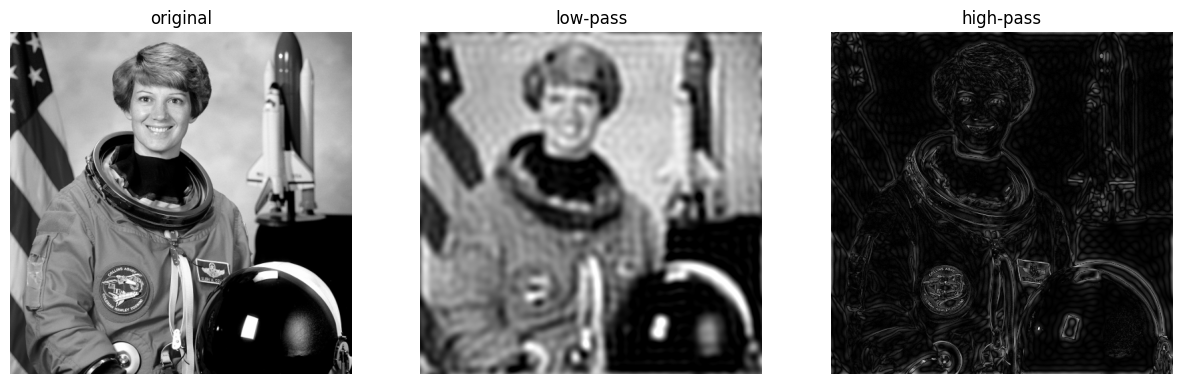

In [12]:

# TODO (Optional): STUDENT IMPLEMENTATION
# Hints:
F = np.fft.fftshift(np.fft.fft2(img_gray.astype(np.float32)))
# Make a circular mask with radius R around the center
# Apply mask: F_lp = F * mask; F_hp = F * (1-mask)
# Reconstruct: np.real(np.fft.ifft2(np.fft.ifftshift(F_lp)))


h, w = img_gray.shape
cy, cx = h // 2, w // 2
R = 30
Y, X = np.ogrid[:h, :w]
distance = np.sqrt((X - cx)**2 + (Y - cy)**2)
mask = (distance <= R).astype(float)
F_lp = F * mask
F_hp = F * (1 - mask)
img_lp = np.real(
    np.fft.ifft2(
        np.fft.ifftshift(F_lp)
    )
)
img_hp = np.real(
    np.fft.ifft2(
        np.fft.ifftshift(F_hp)
    )
)
img_lp = np.clip(img_lp, 0, 255).astype(np.uint8)

img_hp = np.abs(img_hp)
img_hp = img_hp / img_hp.max() * 255
img_hp = img_hp.astype(np.uint8)

show_side_by_side(
    [img_gray, img_lp, img_hp],
    ["original", "low-pass", "high-pass"],
    ["gray", "gray", "gray"],
    size=5
)


---
## Reflection (8–12 sentences)
Briefly answer:
- Which implementation detail was most error-prone (padding, flipping, dtype)?  
- Effect of increasing σ in Gaussian on noise vs edges?  
- Sobel vs Laplacian differences?  
- When prefer Canny over Sobel?  
- Spatial vs Frequency: one scenario where each is preferable.


## My Answers:
- The most error-prone detail was padding because it affects both output size and border values.
- Increasing σ in Gaussian filtering smooths more noise but also removes more edge details.
- Sobel detects edges using horizontal and vertical gradients, while Laplacian uses the second derivative.
- I would prefer Canny when cleaner and thinner edges are needed.
Sobel is simpler when I mainly need gradient magnitude and direction.
Spatial filtering is useful for common operations such as blurring and edge detection.
- Frequency-domain filtering is preferable when I need to remove specific frequencies or periodic noise.


- Overall, both approaches are useful depending on whether I need pixel-level operations or frequency control.


---
## Grading Rubric (20 pts)
- A. Convolution implemented correctly — 6  
- B. Gaussian kernel built + applied — 4  
- C. Sobel magnitude — 4  
- D. Laplacian + comparison — 3  
- Reflection quality — 3  
- **(+2 EC)** Optional FFT filters
